Problem 1 : Longest Stable Subsequence
Consider a list of numbers  [𝑎0,𝑎1,⋯,𝑎𝑛−1]
 . Our goal is to find the the longest stable subsequence:  [𝑎𝑖1,𝑎𝑖2,⋯,𝑎𝑖𝑘]
  which is a sub-list of the original list that selects elements at indices  𝑖1,𝑖2,…,𝑖𝑘
  from the original list such that

𝑖1<𝑖2<⋯<𝑖𝑘
 ;
𝑎𝑖𝑗+1−1≤𝑎𝑖𝑗≤𝑎𝑖𝑗+1+1
 . We can also write this as  |𝑎𝑖𝑗+1−𝑎𝑖𝑗|≤1
 . I.e, each element of the subsequence must be within  ±1
  or equal to the previous element.
The length of the subsequence  𝑘
  is maximized.
Example
Consider the list [1, 4, 2, -2, 0, -1, 2, 3]. There are many "stable subsequences":

[1, 0, -1]
[1, 2, 2, 3]
[4, 3]
The longest stable subsequence is [1, 2, 2, 3] of length 4. Note that each element of the subsequence is at most  1
  away from the previous element.

The goal of this problem is to formulate a dynamic programming solution to find the length of the longest stable subsequence and the subsequence itself.

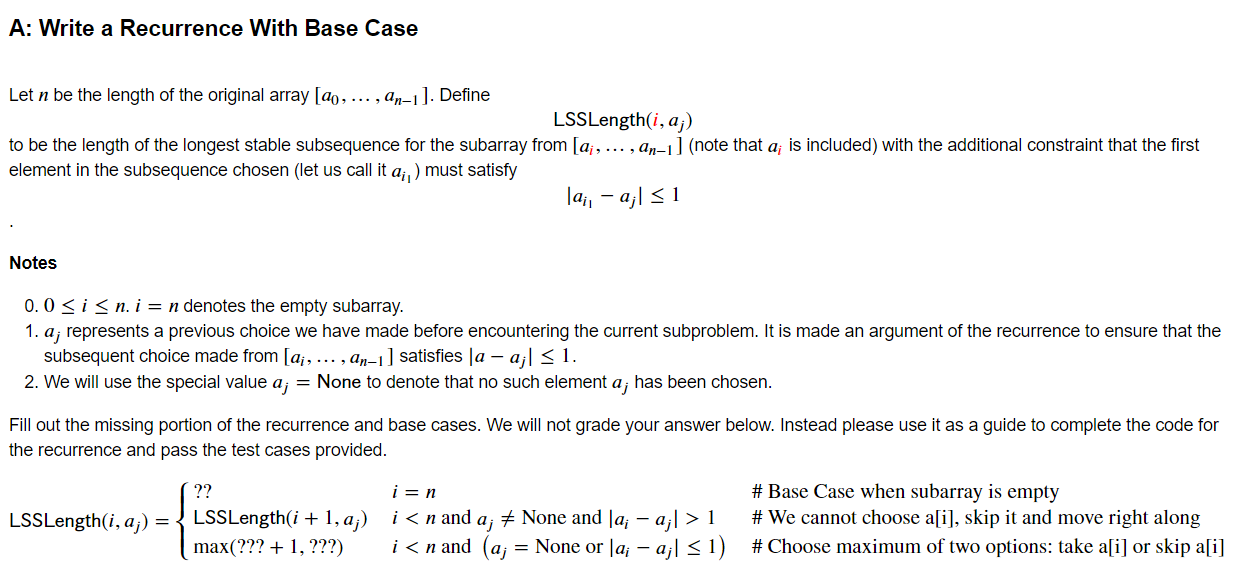

In [18]:
# Program the recurrence for longest stable subsequence
# 0 <= i <= len(a)
# Note that if j == -1, then take aj = None
# else aj = a[j]
def lssLength(a, i, j):
    aj = a[j] if 0 <= j < len(a) else None 
    # Implement the recurrence below. Use recursive calls back to lssLength
    # your code here
    if (i == len(a)):
        return 0
    elif(aj is None or abs(a[i]-aj)<=1):
        len1 = lssLength(a,i+1, i)
        len2 = lssLength(a,i+1,j)
        return max(len1 + 1, len2)
    else:
        return lssLength(a,i+1, j)
    
    

In [20]:
print('--Test1--')
n1 = lssLength([1, 4, 2, -2, 0, -1, 2, 3],0, -1)
print(n1)
assert n1== 4, f'Test 1 failed: expected answer 4, your code: {n1}'
print('passed')

print('--Test2--')
n2 = lssLength([1, 2, 3, 4, 0, 1, -1, -2, -3, -4, 5, -5, -6], 0, -1)
print(n2)
assert n2 == 8, f'Test 2 failed: expected answer 8, your code: {n2}'

print('--Test3--')
n3 = lssLength([0,2, 4, 6, 8, 10, 12],0, -1)
print(n3)
assert n3 == 1, f'Test 3 failed: expected answer 1, your code: {n3}'


print('--Test 4--')
n4 = lssLength([4,8, 7, 5, 3, 2, 5, 6, 7, 1, 3, -1, 0, -2, -3, 0, 1, 2, 1, 3, 1, 0, -1, 2, 4, 5, 0, 2, -3, -9, -4, -2, -3, -1], 0, -1)
print(n4)
assert n4 == 14, f'Test 4 failed: expected answer 14, your code: {n4}'

print('All Tests Passed (8 points)')

--Test1--
4
passed
--Test2--
8
--Test3--
1
--Test 4--
14
All Tests Passed (8 points)


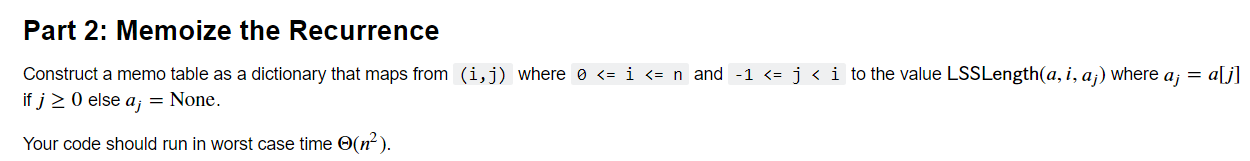

In [33]:
def memoizeLSS(a):
    T = {} # Initialize the memo table to empty dictionary
    # Now populate the entries for the base case 
    n = len(a)
    for j in range(-1, n):
        T[(n, j)] = 0 # i = n and j 
    # Now fill out the table : figure out the two nested for loops
    # It is important to also figure out the order in which you iterate the indices i and j
    # Use the recurrence structure itself as a guide: see for instance that T[(i,j)] will depend on T[(i+1, j)]
    # your code here
    for i in range(n-1, -1, -1):  # Iterate in reverse order for i
        for j in range(i-1, -2, -1):  # Iterate in reverse order for j
            aj = a[j] if j >= 0 else None
            if j == -1 or (aj is not None and abs(a[i] - aj) <= 1):
                T[(i, j)] = max(1 + T[(i+1, i)], T[(i+1, j)])
            else:
                T[(i, j)] = T[(i+1, j)]
    return T


In [34]:
def lssLength(a, i, j):
    assert False, 'Redefining lssLength: You should not be calling this function from your memoization code'

def checkMemoTableHasEntries(a, T):
    for i in range(len(a)+1):
        for j in range(i):
            assert (i, j) in T, f'entry for {(i,j)} not in memo table'
            
def checkMemoTableBaseCase(a, T):
    n = len(a)
    for j in range(-1, n):
        assert T[(n, j)] == 0, f'entry for {(n,j)} is not zero as expected'
        
print('-- Test 1 -- ')
a1 = [1, 4, 2, -2, 0, -1, 2, 3]
print(a1)
T1 = memoizeLSS(a1)
checkMemoTableHasEntries(a1, T1)
checkMemoTableBaseCase(a1, T1)
assert T1[(0, -1)] == 4, f'Test 1: Expected answer is 4. your code returns {T1[(0, -1)]}'
print('Passed')


print('--Test2--')
a2 = [1, 2, 3, 4, 0, 1, -1, -2, -3, -4, 5, -5, -6]
print(a2)
T2 = memoizeLSS(a2)
checkMemoTableHasEntries(a2, T2)
checkMemoTableBaseCase(a2, T2)
assert T2[(0, -1)] == 8, f'Test 2: Expected answer is 8. Your code returns {T2[(0, -1)]}'

print('--Test3--')
a3 = [0,2, 4, 6, 8, 10, 12]
print(a3)
T3 = memoizeLSS(a3)
checkMemoTableHasEntries(a3, T3)
checkMemoTableBaseCase(a3, T3)
assert T3[(0, -1)] == 1, f'Test 3: Expected answer is  1. Your code returns {T3[(0, -1)]}'


print('--Test4--')
a4 = [4,8, 7, 5, 3, 2, 5, 6, 7, 1, 3, -1, 0, -2, -3, 0, 1, 2, 1, 3, 1, 0, -1, 2, 4, 5, 0, 2, -3, -9, -4, -2, -3, -1]
print(a4)
T4 = memoizeLSS(a4)
checkMemoTableHasEntries(a4, T4)
checkMemoTableBaseCase(a4, T4)
assert T4[(0, -1)] == 14, f'Text 4: Expected answer is 14. Your code returns {T4[(0,-1)]}'

print('All tests passed (7 points)')

-- Test 1 -- 
[1, 4, 2, -2, 0, -1, 2, 3]
Passed
--Test2--
[1, 2, 3, 4, 0, 1, -1, -2, -3, -4, 5, -5, -6]
--Test3--
[0, 2, 4, 6, 8, 10, 12]
--Test4--
[4, 8, 7, 5, 3, 2, 5, 6, 7, 1, 3, -1, 0, -2, -3, 0, 1, 2, 1, 3, 1, 0, -1, 2, 4, 5, 0, 2, -3, -9, -4, -2, -3, -1]
All tests passed (7 points)


Part 3: Modify Memoized Code to Recover Solution
Write a function computeLSS(a) that modifies the memo table to allow you to recover the longest stable subsequence as well as its length. computeLSS should return the longest stable subsequence of the input a as a list.

In [37]:


def memoizeLSS(a):
    T = {} #  memo table initialized to an empty dictionary
    n = len(a)
    
    # entries for base case
    for j in range(-1, n):
        T[(n, j)] = (0, [])  # i = n and j
    
    # Fill the memo table
    for i in range(n-1, -1, -1):  # Iterate in reverse for i
        for j in range(-1, n):  # Iterate all possible values of j
            aj = a[j] if j >= 0 else None
            if j == -1 or (aj is not None and abs(a[i] - aj) <= 1):
                length, sequence = max((1 + T[(i+1, i)][0], [a[i]] + T[(i+1, i)][1]), T[(i+1, j)], key=lambda x: x[0])
            else:
                length, sequence = T[(i+1, j)]
            T[(i, j)] = (length, sequence)
    
    return T

def computeLSS(a):
    T = memoizeLSS(a)
    maximumLength = 0
    maximumSequence = []
    n = len(a)
    # Find the maximum length and corresponding ending index from the memo table
    for j in range(-1, n):
        (length, sequence) = T[(0, j)]
        if length > maximumLength:
            maximumLength = length
            maximumSequence = sequence
    return maximumSequence

In [38]:
## BEGIN TESTS 
def checkSubsequence(a, b):
    i = 0
    j = 0
    n = len(a)
    m = len(b)
    for j in range(m-1):
        assert abs(b[j] - b[j+1]) <= 1
    while (i < n and j < m):
        if a[i] == b[j]: 
            j = j + 1
        i = i + 1
    if j < m:
        return False
    return True 

print('--Test 1 --')
a1 = [1, 4, 2, -2, 0, -1, 2, 3]
print(a1)
sub1 = computeLSS(a1)
print(f'sub1 = {sub1}')
assert len(sub1) == 4, f'Subsequence does not have length 4'
assert checkSubsequence(a1, sub1), f'Your solution is not a subsequence of the original sequence'

print('--Test2--')
a2 = [1, 2, 3, 4, 0, 1, -1, -2, -3, -4, 5, -5, -6]
print(a2)
sub2 = computeLSS(a2)
print(f'sub2 = {sub2}')
assert len(sub2) == 8
assert checkSubsequence(a2, sub2)

print('--Test3--')
a3 = [0,2, 4, 6, 8, 10, 12]
print(a3)
sub3 = computeLSS(a3)
print(f'sub3 = {sub3}')
assert len(sub3) == 1
assert checkSubsequence(a3, sub3)



print('--Test4--')
a4 = [4,8, 7, 5, 3, 2, 5, 6, 7, 1, 3, -1, 0, -2, -3, 0, 1, 2, 1, 3, 1, 0, -1, 2, 4, 5, 0, 2, -3, -9, -4, -2, -3, -1]
print(a4)
sub4 = computeLSS(a4)
print(f'sub4 = {sub4}')
assert len(sub4) == 14
assert checkSubsequence(a4, sub4)

print('All test passed (10 points)')
## END TESTS

--Test 1 --
[1, 4, 2, -2, 0, -1, 2, 3]
sub1 = [1, 2, 2, 3]
--Test2--
[1, 2, 3, 4, 0, 1, -1, -2, -3, -4, 5, -5, -6]
sub2 = [1, 0, -1, -2, -3, -4, -5, -6]
--Test3--
[0, 2, 4, 6, 8, 10, 12]
sub3 = [0]
--Test4--
[4, 8, 7, 5, 3, 2, 5, 6, 7, 1, 3, -1, 0, -2, -3, 0, 1, 2, 1, 3, 1, 0, -1, 2, 4, 5, 0, 2, -3, -9, -4, -2, -3, -1]
sub4 = [4, 3, 2, 1, 0, 0, 1, 2, 1, 1, 0, -1, 0, -1]
All test passed (10 points)


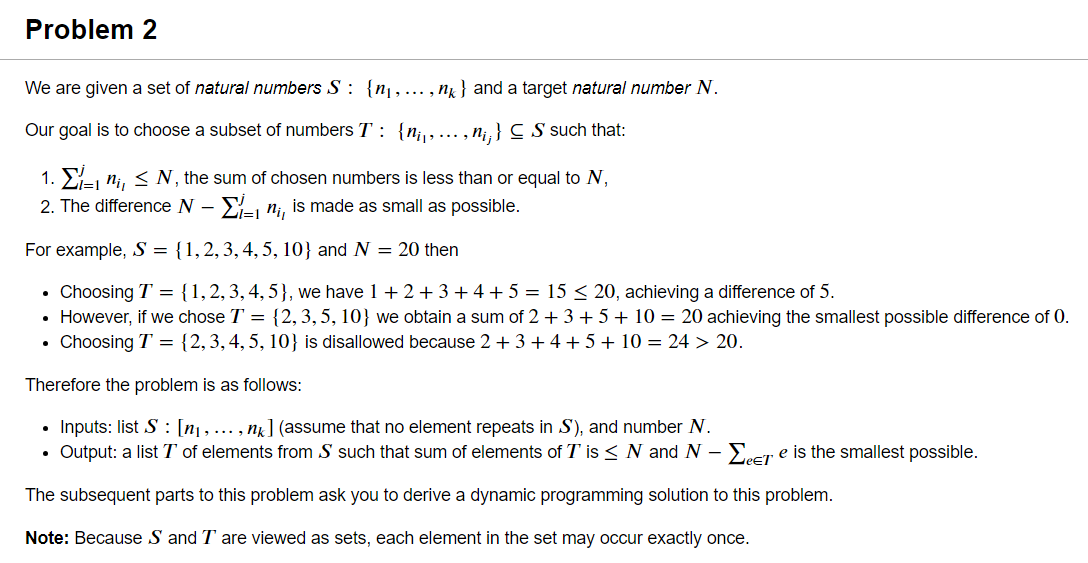

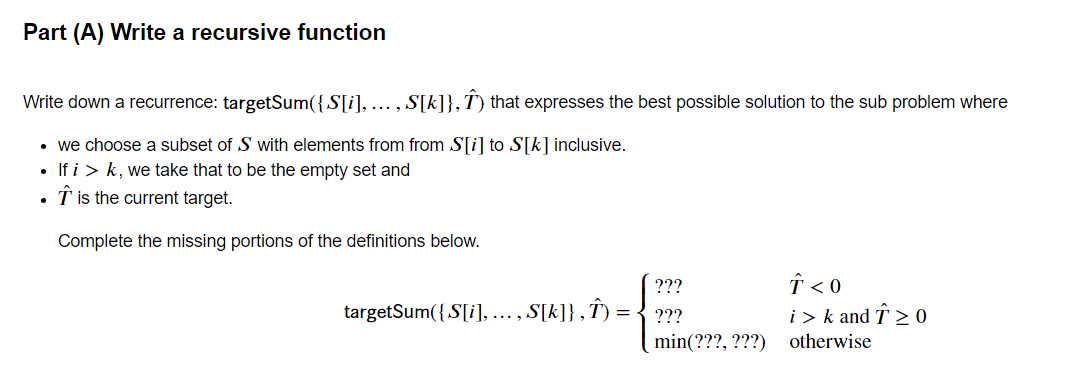

We start with first element (i=0) and given tgt. We can either include or exclude this element from optimal subsequence. We call recursively for next element (i+1) which has wither tgt-S[i] or tgt remaining correspondingly. We take the minimum remaining returned by either of these 2 choices. End conditions are when either tgt becomes less than 0 => this path is not feasible and we return huge number float(inf) or when i goes out of bounds of array's end element (i > len(S) -1) when we return whatever tgt remains at that point

In [5]:
cache = {}

def targetSum(S, i, tgt):
    if tgt < 0:
        return float('inf')
    elif i > len(S) - 1:
        return abs(tgt)
    else:
        if (i+1,tgt-S[i],1) in cache:
            include_current = cache[(i+1,tgt-S[i],1)]
        else:
            include_current = targetSum(S, i + 1, tgt - S[i])
            cache[(i+1,tgt-S[i],1)] = include_current

        if (i+1,tgt-S[i],0) in cache:
            exclude_current = cache[(i+1,tgt-S[i],0)]
        else:
            exclude_current = targetSum(S, i + 1, tgt)
            cache[(i+1,tgt-S[i],0)] = exclude_current
        return min(include_current, exclude_current)

In [6]:
def tgtSum(tgt, S):
    return targetSum(S, 0, tgt)

t1 = tgtSum(15, [1, 2, 3, 4, 5, 10]) # Should be zero
assert t1 == 0, 'Test 1 failed'

t2 = tgtSum(26, [1, 2, 3, 4, 5, 10]) # should be 1
assert t2 == 1, 'Test 2 failed'

t3 = (tgtSum(23, [1, 2, 3, 4, 5, 10])) # should be 0
assert t3 == 0, 'Test 3 failed'


t4 = (tgtSum(18, [1, 2, 3, 4, 5, 10])) # should be 0
assert t4 == 0, 'Test 4 failed'

t5 = (tgtSum(9, [1, 2, 3, 4, 5, 10])) # should be 0
assert t5 == 0, 'Test 5 failed'

t6 = (tgtSum(457, [11, 23, 37, 48, 94, 152, 230, 312, 339, 413])) # should be 1
assert t6 == 1, 'Test 6 failed'

t7 = (tgtSum(512, [11, 23, 37, 48, 94, 152, 230, 312, 339, 413])) # should be 0
assert t7 == 0, 'Test 7 failed'

t8 = (tgtSum(616, [11, 23, 37, 48, 94, 152, 230, 312, 339, 413])) # should be 1
assert t8 == 1, 'Test 8 failed'

print('All tests passed (10 points)!')

All tests passed (10 points)!


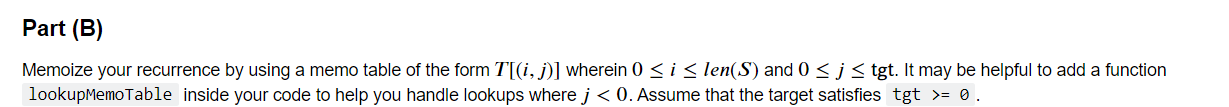

In [41]:
def memoTargetSum(S, tgt): # almost similar to knapsack dynamic programming
    k = len(S)
    assert tgt >= 0
    ## Fill in base case for T[(i,j)] where i == k
    T = {} # Memo table initialized as empty dictionary
    for j in range(tgt+1):
        T[(k,j)] = j # when no more items are there in array the 'target' value will be returned
    
    # your code here
    for i in range(k-1, -1, -1): # since we need i+1 for calculating i, we start from end of range to 0
        for j in range(tgt + 1): # since we need j-S[i] to calculate T[(i,j)] we calculate tagt from 0 to range
            optA = T[(i + 1, j)] # corresponds to exclude current item
            if j - S[i] >= 0:
                optB = T[(i + 1, j - S[i])] # corresponds to  include current item
            else:
                optB = float('inf')
            T[(i, j)] = min(optA, optB)
                
    return T

In [42]:
def checkMemoTblTargetSum(a, tgt, expected):
    T = memoTargetSum(a, tgt)
    for i in range(len(a)+1):
        for j in range(tgt+1):
            assert (i, j) in T, f'Memo table fails to have entry for i, j = {(i, j)}'
    assert T[(0,tgt)] == expected, f'Expected answer = {expected}, your code returns {T[(0, tgt)]}'
    return 

print('--test 1--')
a1 = [1, 2, 3, 4, 5, 10]
print(a1, 15)
checkMemoTblTargetSum(a1, 15, 0)

print('--test 2--')
a2= [1, 2, 3, 4, 5, 10]
print(a2, 26)
checkMemoTblTargetSum(a2, 26, 1)

print('--test3--')
a3= [11, 23, 37, 48, 94, 152, 230, 312, 339, 413]
print(a3, 457)
checkMemoTblTargetSum(a3, 457, 1)

print('--test4--')
print(a3, 512)
checkMemoTblTargetSum(a3, 512, 0)

print('--test5--')
print(a3, 616)
checkMemoTblTargetSum(a3, 616, 1)
print('All tests passed (10 points)!')


--test 1--
[1, 2, 3, 4, 5, 10] 15
--test 2--
[1, 2, 3, 4, 5, 10] 26
--test3--
[11, 23, 37, 48, 94, 152, 230, 312, 339, 413] 457
--test4--
[11, 23, 37, 48, 94, 152, 230, 312, 339, 413] 512
--test5--
[11, 23, 37, 48, 94, 152, 230, 312, 339, 413] 616
All tests passed (10 points)!


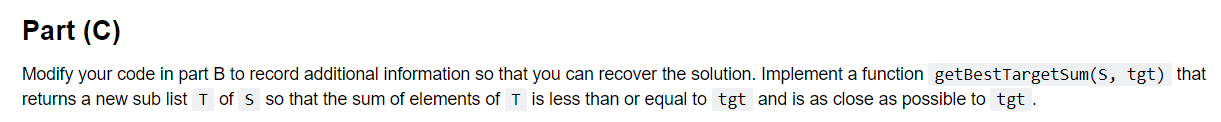

In [43]:
def getBestTargetSum(S, tgt):
    k = len(S)
    assert tgt >= 0
    # your code here
    j = tgt
    i = 0
    Table = memoTargetSum(S, tgt)
    res = []
    
    while i < k:
        currentCell = Table[(i, j)]
        cellBelow = Table[(i + 1, j)]
        
        if currentCell != cellBelow:
            #Use S[i]
            res.append(S[i])
            j = j - S[i]
        
        i = i + 1
    
    return res  

In [44]:
def checkTgtSumRes(a, tgt,expected):
    a = sorted(a)
    res = getBestTargetSum(a, tgt)
    res = sorted(res)
    print('Your result:' , res)
    assert tgt - sum(res)  == expected, f'Your code returns result that sums up to {sum(res)}, expected was {expected}'
    i = 0
    j = 0
    n = len(a)
    m = len(res)
    while (i < n and j < m):
        if a[i] == res[j]: 
            j = j + 1
        i = i + 1
    assert j == m, 'Your result  {res} is not a subset of {a}'


print('--test 1--')
a1 = [1, 2, 3, 4, 5, 10]
print(a1, 15)
checkTgtSumRes(a1, 15, 0)

print('--test 2--')
a2 = [1, 8, 3, 4, 5, 12]
print(a2, 26)
checkTgtSumRes(a2, 26, 0)

print('--test 3--')
a3 = [8, 3, 2, 4, 5, 7, 12]
print(a3, 38)
checkTgtSumRes(a3, 38, 0)

print('--test 4 --')
a4 = sorted([1, 10, 19, 18, 12, 11, 0, 9,  16, 17, 2, 7, 14, 29, 38, 45, 13, 26, 51, 82, 111, 124, 135, 189])
print(a4)
checkTgtSumRes(a4, 155, 0)
print('--test 5--')
checkTgtSumRes(a4, 189, 0)

print('--test 7--')
checkTgtSumRes(a4, 347, 0)

print('--test 8--')
checkTgtSumRes(a4, 461, 0)


print('--test 9--')
checkTgtSumRes(a4, 462, 0)


print('--test 9--')
checkTgtSumRes(a4, 517, 0)


print('--test 10--')
checkTgtSumRes(a4, 975, 3)

print('All Tests Passed (15 points)')



--test 1--
[1, 2, 3, 4, 5, 10] 15
Your result: [5, 10]
--test 2--
[1, 8, 3, 4, 5, 12] 26
Your result: [1, 5, 8, 12]
--test 3--
[8, 3, 2, 4, 5, 7, 12] 38
Your result: [2, 4, 5, 7, 8, 12]
--test 4 --
[0, 1, 2, 7, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 26, 29, 38, 45, 51, 82, 111, 124, 135, 189]
Your result: [18, 26, 111]
--test 5--
Your result: [189]
--test 7--
Your result: [29, 38, 45, 111, 124]
--test 8--
Your result: [26, 111, 135, 189]
--test 9--
Your result: [38, 111, 124, 189]
--test 9--
Your result: [82, 111, 135, 189]
--test 10--
Your result: [1, 2, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 26, 29, 38, 45, 51, 82, 111, 124, 135, 189]
All Tests Passed (15 points)


: 